/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
Accuracy: 0.7882
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

=== Random Forest ===
Accuracy: 0.7861
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



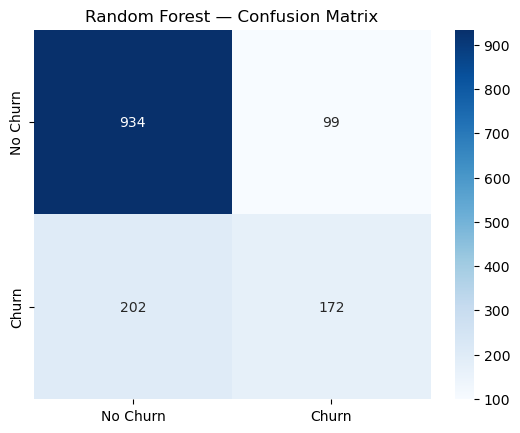

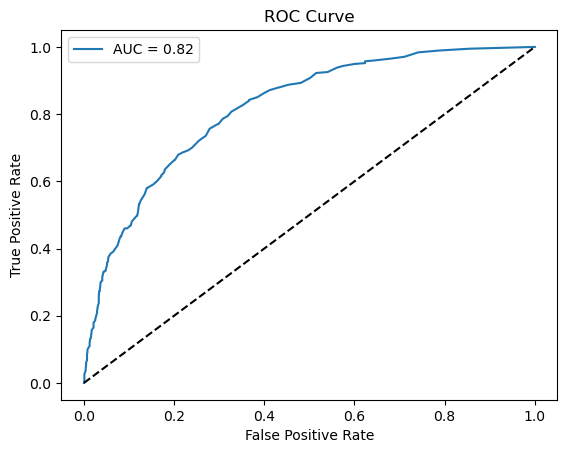

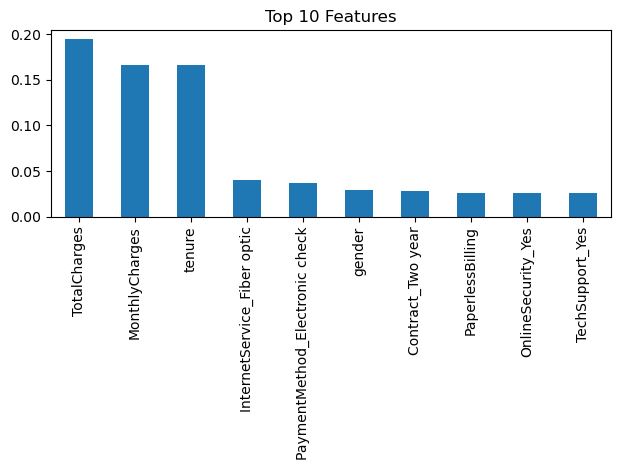

Model saved.


In [6]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

with open('train_test_data.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))


def plot_confusion_matrix(y_true, y_pred, labels, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title('Random Forest — Confusion Matrix')
    fig.savefig(save_path)
    plt.show()


def plot_roc_curve(model, X_test, y_test, save_path):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)

    fig, ax = plt.subplots()
    ax.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend()
    fig.savefig(save_path)
    plt.show()


def plot_feature_importance(model, feature_names, top_n=10, save_path='feature_importance.png'):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top_features = importances.nlargest(top_n)

    fig, ax = plt.subplots()
    top_features.plot(kind='bar', ax=ax)
    ax.set_title(f'Top {top_n} Features')
    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()


plot_confusion_matrix(y_test, rf_preds, ['No Churn', 'Churn'], 'confusion_matrix.png')
plot_roc_curve(rf, X_test, y_test, 'roc_curve.png')
plot_feature_importance(rf, X_train.columns)

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Model saved.")